# Defense News Classifier — Eval Analysis

Loads the outputs from `evals/` and `data/` to explore classifier performance interactively.

Run `uv run python src/eval.py` first to generate the files this notebook reads.

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns

# Load ground truth + predictions (merged)
df = pd.read_csv('../data/synthetic_articles.csv')
preds = pd.read_csv('../evals/predictions.csv')
merged = df.merge(preds, on='id')

print(f'Articles: {len(merged)}')

Articles: 300


## Overall accuracy

In [5]:
cat_acc = (merged['category'] == merged['pred_category']).mean()
dom_acc = (merged['operational_domain'] == merged['pred_operational_domain']).mean()

print(f'Category accuracy           : {cat_acc:.1%}')
print(f'Operational domain accuracy : {dom_acc:.1%}')

Category accuracy           : 79.0%
Operational domain accuracy : 97.3%


## Confusion matrices

Rows = true label, columns = predicted label. Diagonal = correct predictions.

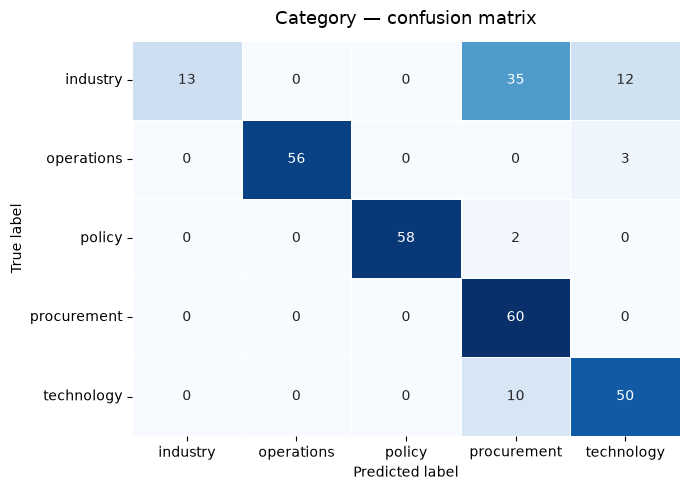

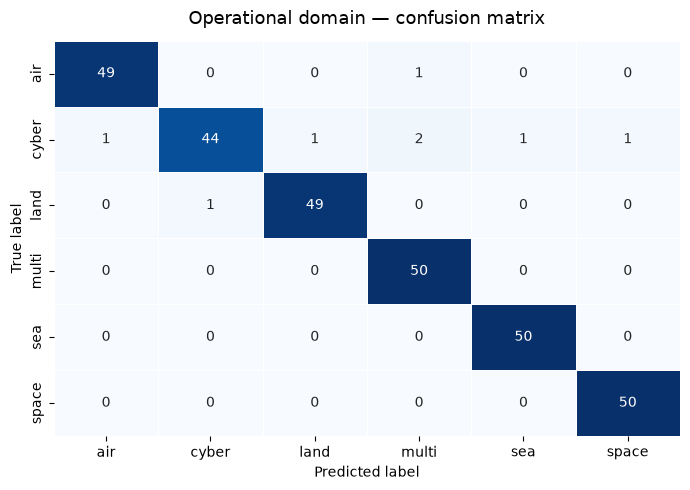

In [6]:
def plot_confusion(df, true_col, pred_col, title):
    labels = sorted(df[true_col].unique())
    cm = pd.crosstab(
        df[true_col], df[pred_col],
        rownames=['True'], colnames=['Predicted']
    ).reindex(index=labels, columns=labels, fill_value=0)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        linewidths=0.5, ax=ax, cbar=False
    )
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion(merged, 'category', 'pred_category', 'Category — confusion matrix')
plot_confusion(merged, 'operational_domain', 'pred_operational_domain', 'Operational domain — confusion matrix')

## Per-label metrics

In [7]:
def per_label_metrics(df, true_col, pred_col):
    labels = sorted(df[true_col].unique())
    rows = []
    for label in labels:
        tp = int(((df[true_col] == label) & (df[pred_col] == label)).sum())
        fp = int(((df[true_col] != label) & (df[pred_col] == label)).sum())
        fn = int(((df[true_col] == label) & (df[pred_col] != label)).sum())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append({'label': label, 'precision': precision, 'recall': recall, 'f1': f1, 'support': tp + fn})
    return pd.DataFrame(rows).set_index('label')

print('--- Category ---')
display(per_label_metrics(merged, 'category', 'pred_category').style.format('{:.3f}', subset=['precision','recall','f1']))

print('\n--- Operational domain ---')
display(per_label_metrics(merged, 'operational_domain', 'pred_operational_domain').style.format('{:.3f}', subset=['precision','recall','f1']))

--- Category ---


,precision,recall,f1,support
label,,,,
industry,1.000,0.217,0.356,60
operations,1.000,0.933,0.966,60
policy,1.000,0.967,0.983,60
procurement,0.561,1.000,0.719,60
technology,0.769,0.833,0.800,60



--- Operational domain ---


,precision,recall,f1,support
label,,,,
air,0.980,0.980,0.980,50
cyber,0.978,0.880,0.926,50
land,0.980,0.980,0.980,50
multi,0.943,1.000,0.971,50
sea,0.980,1.000,0.990,50
space,0.980,1.000,0.990,50


## Per-label F1 — bar chart

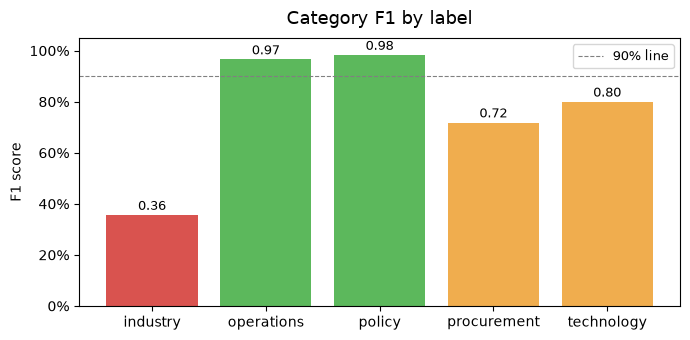

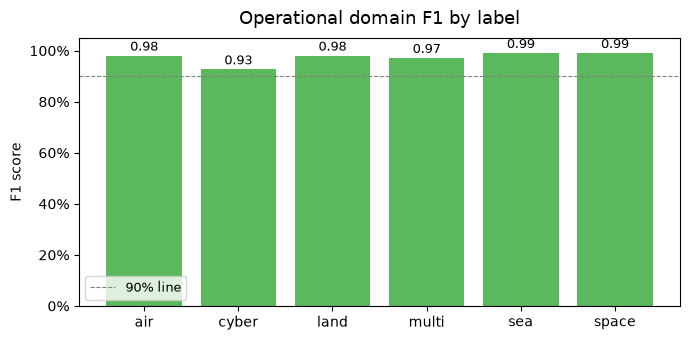

In [8]:
def plot_f1(metrics_df, title):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    colors = ['#d9534f' if v < 0.7 else '#5cb85c' if v >= 0.9 else '#f0ad4e' for v in metrics_df['f1']]
    ax.bar(metrics_df.index, metrics_df['f1'], color=colors)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1 score')
    ax.set_title(title, fontsize=13, pad=10)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, label='90% line')
    ax.legend(fontsize=9)
    for i, (label, row) in enumerate(metrics_df.iterrows()):
        ax.text(i, row['f1'] + 0.02, f"{row['f1']:.2f}", ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_f1(per_label_metrics(merged, 'category', 'pred_category'), 'Category F1 by label')
plot_f1(per_label_metrics(merged, 'operational_domain', 'pred_operational_domain'), 'Operational domain F1 by label')

## Misclassifications

Every article where at least one field was predicted wrong.

In [9]:
misclass = merged[
    (merged['category'] != merged['pred_category']) |
    (merged['operational_domain'] != merged['pred_operational_domain'])
][['id', 'text', 'category', 'pred_category', 'operational_domain', 'pred_operational_domain']].reset_index(drop=True)

print(f'Misclassified: {len(misclass)} / {len(merged)} ({len(misclass)/len(merged):.1%})')
misclass

Misclassified: 67 / 300 (22.3%)


,id,text,category,pred_category,operational_domain,pred_operational_domain
0,62,U.S. Air Force B-52H Stratofortress bombers fr...,operations,operations,air,multi
1,67,South Korean KF-21 Boramae prototypes complete...,operations,technology,air,air
2,81,The French Navy frigate FS Provence conducted ...,operations,technology,sea,sea
3,94,France's Commandement de la Cyberdéfense (COMC...,operations,operations,cyber,multi
4,95,South Korea's Defense Security Support Command...,operations,cyber,cyber,cyber
...,...,...,...,...,...,...
62,295,Northrop Grumman has secured a $1.7 billion co...,industry,procurement,multi,multi
63,296,Japan's Mitsubishi Electric Corporation has be...,industry,procurement,multi,multi
64,297,Turkey's ASELSAN has announced a landmark expo...,industry,procurement,multi,multi
65,298,General Dynamics Mission Systems has partnered...,industry,procurement,multi,multi


### Where did `industry` go?

Industry has the worst recall — filter to see what it was mistaken for.

In [10]:
industry_errors = misclass[misclass['category'] == 'industry'][['text', 'category', 'pred_category']]
print(f'{len(industry_errors)} industry articles misclassified as:')
print(industry_errors['pred_category'].value_counts().to_string())
print()
industry_errors

48 industry articles misclassified as:
pred_category
procurement    35
technology     12
industry        1



,text,category,pred_category
19,Lockheed Martin has secured a $4.2 billion con...,industry,procurement
20,Airbus Defence & Space has announced a strateg...,industry,technology
21,BAE Systems has completed the first full-rate ...,industry,procurement
22,Israeli aerospace giant Elbit Systems has unve...,industry,technology
23,South Korean aerospace firm Korea Aerospace In...,industry,procurement
24,Rolls-Royce has been awarded a £1.7 billion co...,industry,procurement
25,"Boeing's Defense, Space & Security division ha...",industry,procurement
26,Turkish defense company ROKETSAN has successfu...,industry,technology
27,French defense and aerospace group Dassault Av...,industry,procurement
28,Rheinmetall AG has secured a €2.1 billion cont...,industry,procurement
